# NOVAPAY

### Import Libraries

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import shap
shap.initjs()

import warnings
warnings.filterwarnings("ignore")

In [131]:
# Load data
df_raw = pd.read_csv("/home/whizic/UK/AMDARI/NOVAPAY/nova_pay_combined.csv")
df = df_raw.copy()
df.shape

(11400, 26)

In [132]:
df.head(5)

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [133]:
# Check for missing values
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [134]:
# check for data types
df.dtypes

transaction_id                object
customer_id                   object
timestamp                     object
home_country                  object
source_currency               object
dest_currency                 object
channel                       object
amount_src                    object
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
device_id                     object
new_device                      bool
ip_address                    object
ip_country                    object
location_mismatch               bool
ip_risk_score                float64
kyc_tier                      object
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h                int64
txn_velocity_24h               int64
corridor_risk                float64
is_fraud                       int64
dtype: object

In [135]:
# examine the distribution of the target variable
df["is_fraud"].value_counts(normalize=True)

# from the output below, a simple model that predicts all transactions as non-fraudulent would achieve an accuracy of 91.25%, which is not a good metric here.
# Use prescision, recall, F1-score, and AUC-ROC or resampling techniques to evaluate the model performance.

is_fraud
0    0.912544
1    0.087456
Name: proportion, dtype: float64

### Data Cleaning

In [136]:
# convert timestamp to datetime, coercing invalid values to NaT (Not a Time)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [137]:
# convert amouunt_src to numeric float, setting non-numeric values to NaN
df['amount_src'] = (
    df['amount_src']
      .astype(str)
      .str.replace(',', '', regex=False)
      .str.strip()
)
df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')

In [138]:
# amount in source currency have no missing values, but amount in USD has missing values. This could be a conversion(exchange) rate issue.
# calculate exchange rate per currency
# select only the rows where amount_usd is not null
# group by source_currency
# calculate the mean exchange rate for each source_currency
# convert the result to a dictionary for easy lookup
exchange_rates = df[df['amount_usd'].notna()].groupby('source_currency').apply(lambda x: (x['amount_usd'] / x['amount_src']).mean()).to_dict()

In [139]:
# display the exchange rates for each source currency
exchange_rates

{'CAD': 0.7216095926871465,
 'GBP': 1.2234540399539093,
 'USD': 0.9838792221084954}

In [140]:
# check for all source currencies in the dataset
df['source_currency'].value_counts()

source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

In [141]:
# fill in missing amount_usd values using the calculated exchange rates
# if amount_usd is already present, keep it; 
# if not, calculate it using amount_src multiplied by the exchange rate for the corresponding source_currency
# default to 1 if the currency is not found in the exchange_rates dictionary
df['amount_usd'] = df.apply(
  lambda row: row['amount_usd'] if pd.notna(row['amount_usd']) else row['amount_src'] * exchange_rates.get(row['source_currency'], 1), axis=1) 

In [142]:
# fill missing values for fee using the median of the channel
# then fill any remaining missing values with the overall median
df['fee'] = df.groupby('channel')['fee'].transform(lambda x: x.fillna(x.median()))

In [143]:
# fill missing ip_country with the equivalent home_country
if {'ip_country', 'home_country'}.issubset(df.columns):
    df['ip_country'] = df['ip_country'].fillna(df['home_country'])


In [144]:
# fill missing data for kyc_tier using the mode
if 'kyc_tier' in df.columns:
    mode_kyc_tier = df['kyc_tier'].mode().iloc[0] if not df['kyc_tier'].mode().empty else "standard"  # default to "standard" if mode is empty
    df['kyc_tier'] = df['kyc_tier'].fillna(mode_kyc_tier)

In [145]:
# fill missing value for device_trust_score
# if device_trust_score and kyc_tier are present, fill missing score per group using the group median 
# fill any remaining missing values with the overall median
if 'device_trust_score' in df.columns and 'kyc_tier' in df.columns:
    df['device_trust_score'] = df.groupby('kyc_tier')['device_trust_score'].transform(lambda x: x.fillna(x.median()))
    df['device_trust_score'] = df['device_trust_score'].fillna(df['device_trust_score'].median())

In [146]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     61
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                            0
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                     0
location_mismatch              0
ip_risk_score                  0
kyc_tier                       0
account_age_days               0
device_trust_score             0
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [147]:
df.dropna(inplace=True)

In [148]:
df.shape

(11034, 26)

In [149]:
### Sanity Checks
df.describe(include='all')

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,11034,11034,11034,11034,11034,11034,11034,11034.000000,11034.000000,11034.000000,...,11034.000000,11034,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000,11034.000000
unique,10840,1314,NaN,7,3,9,12,NaN,NaN,NaN,...,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,7e762adf-98c5-48e5-900a-b6afee5ade30,402cccc9-28de-45b3-9af7-cc5302aa1f93,NaN,US,USD,NGN,mobile,NaN,NaN,NaN,...,NaN,standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1458,NaN,7687,7773,1426,6136,NaN,NaN,NaN,...,NaN,7885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2024-05-03 12:57:12.877111296+00:00,NaN,NaN,NaN,NaN,440.498887,451.585603,98.186659,...,0.397754,NaN,392.967917,0.654239,0.050027,0.268048,0.469730,0.739804,0.045556,0.089451
min,NaN,NaN,2022-10-03 18:40:59.468549+00:00,NaN,NaN,NaN,NaN,-9997.160000,7.230000,-1.000000,...,0.004000,NaN,1.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,2023-08-15 04:32:57.718548992+00:00,NaN,NaN,NaN,NaN,90.895000,92.570000,2.382500,...,0.209000,NaN,147.000000,0.515000,0.000000,0.169000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,2024-05-09 05:02:37.968549120+00:00,NaN,NaN,NaN,NaN,159.120000,163.645000,3.510000,...,0.325000,NaN,286.500000,0.658000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,2025-01-29 13:30:40.468549120+00:00,NaN,NaN,NaN,NaN,295.147500,302.447500,5.550000,...,0.488000,NaN,661.000000,0.894000,0.000000,0.391000,0.000000,0.000000,0.050000,0.000000
max,NaN,NaN,2025-12-16 00:13:41.468549+00:00,NaN,NaN,NaN,NaN,11942.890000,12498.570000,9999.990000,...,1.200000,NaN,1095.000000,0.999000,2.000000,0.900000,8.000000,11.000000,0.250000,1.000000


In [150]:
# count negative values in key numeric columns
numeric_columns = ['amount_src', 'amount_usd', 'fee', 'device_trust_score', 'txn_velocity_1h', 'txn_velocity_24h', 'risk_score_internal']
negative_values_count = {col: (df[col] < 0).sum() for col in numeric_columns}
negative_values_count

{'amount_src': np.int64(100),
 'amount_usd': np.int64(0),
 'fee': np.int64(94),
 'device_trust_score': np.int64(194),
 'txn_velocity_1h': np.int64(194),
 'txn_velocity_24h': np.int64(0),
 'risk_score_internal': np.int64(0)}

In [151]:
# keep only values greater than or equal to zero for the key numeric columns
for col in numeric_columns:
    df = df[df[col] >= 0]

In [152]:
# check for correlation between amount_usd and amount_src
(df["amount_usd"]/df["amount_src"]).describe()

count    10840.000000
mean         1.018123
std          0.136521
min          0.739788
25%          1.000000
50%          1.000000
75%          1.000000
max          1.250405
dtype: float64

In [153]:
# check for future timestamps in the dataset
df[df['timestamp'] > pd.Timestamp.utcnow()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud


In [154]:
# check for location mismatch
df['location_mismatch'].value_counts()

location_mismatch
False    9047
True     1793
Name: count, dtype: int64

In [155]:
# check for unique value counts in categorical columns
categorical_columns = ['home_country', 'source_currency', 'channel', 'dest_currency', 'kyc_tier'] 
unique_value_counts = {col: df[col].unique() for col in categorical_columns}
unique_value_counts

{'home_country': array(['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  '],
       dtype=object),
 'source_currency': array(['USD', 'CAD', 'GBP'], dtype=object),
 'channel': array(['ATM', 'web', 'mobile', 'WEB', ' web  ', 'MOBILE', 'unknown',
        'mobille', ' mobile  ', 'weeb', 'ATm', ' ATM  '], dtype=object),
 'dest_currency': array(['CAD', 'MXN', 'CNY', 'EUR', 'INR', 'GBP', 'PHP', 'NGN', 'USD'],
       dtype=object),
 'kyc_tier': array(['standard', 'enhanced', 'low', ' standard  ', 'standrd',
        ' enhanced  ', 'STANDARD', 'unknown', 'enhancd', ' low  ',
        'ENHANCED', 'LOW'], dtype=object)}

In [156]:
# resolve the spacing in home_country and replace unknown with np.nan
df['home_country'] = df['home_country'].str.strip()

In [157]:
# resolve case sensitivity in channel, spelling errors and unknown values
df['channel'] = df['channel'].str.strip().str.lower()
df['channel'] = df['channel'].replace({'unknown': np.nan, 'weeb': 'web', 'mobille': 'mobile'})


In [158]:
# resolve case sensitivity in kyc_tier and replace unknown with np.nan, and spelling errors
df['kyc_tier'] = df['kyc_tier'].str.strip().str.lower()
df['kyc_tier'] = df['kyc_tier'].replace({'unknown': np.nan, 'standrd': 'standard', 'enhancd': 'enhanced'})

In [159]:
# check for missing values
df.isnull().sum()

transaction_id                0
customer_id                   0
timestamp                     0
home_country                  0
source_currency               0
dest_currency                 0
channel                      36
amount_src                    0
amount_usd                    0
fee                           0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_address                    0
ip_country                    0
location_mismatch             0
ip_risk_score                 0
kyc_tier                     29
account_age_days              0
device_trust_score            0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
is_fraud                      0
dtype: int64

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             10840 non-null  object             
 1   customer_id                10840 non-null  object             
 2   timestamp                  10840 non-null  datetime64[ns, UTC]
 3   home_country               10840 non-null  object             
 4   source_currency            10840 non-null  object             
 5   dest_currency              10840 non-null  object             
 6   channel                    10804 non-null  object             
 7   amount_src                 10840 non-null  float64            
 8   amount_usd                 10840 non-null  float64            
 9   fee                        10840 non-null  float64            
 10  exchange_rate_src_to_dest  10840 non-null  float64            
 11  device_

In [161]:
# drop any remaining rows with missing values
df.dropna(inplace=True)

### Exploratory Data Analysis and Feature Engineering

In [162]:
# explore correlation between numeric features and the target variable
df.corr(numeric_only=True)['is_fraud'].sort_values(ascending=False)

is_fraud                     1.000000
txn_velocity_24h             0.759866
txn_velocity_1h              0.698681
risk_score_internal          0.612653
ip_risk_score                0.591583
chargeback_history_count     0.585117
location_mismatch            0.428793
new_device                   0.389261
corridor_risk                0.198449
exchange_rate_src_to_dest    0.154757
amount_usd                   0.131411
amount_src                   0.130744
fee                          0.130538
account_age_days            -0.291430
device_trust_score          -0.440364
Name: is_fraud, dtype: float64

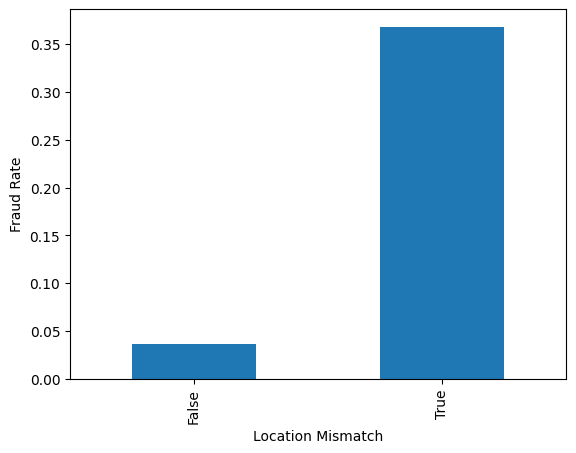

In [163]:

# examine location mismatch with respect to the target variable
df.groupby('location_mismatch')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('Location Mismatch')
plt.show()

In [164]:
# explore correlation between categorical features and the target variable
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols

Index(['transaction_id', 'customer_id', 'home_country', 'source_currency',
       'dest_currency', 'channel', 'device_id', 'ip_address', 'ip_country',
       'kyc_tier'],
      dtype='object')

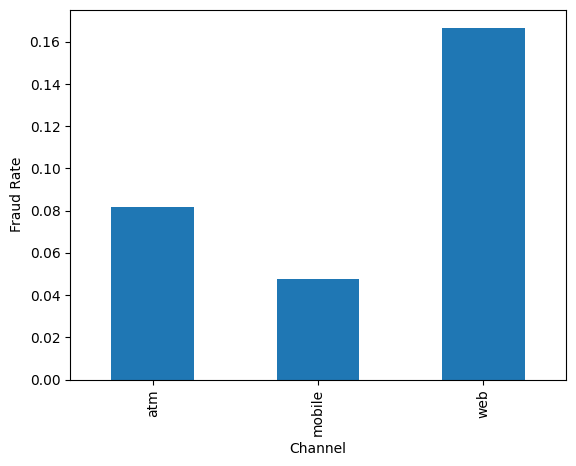

In [165]:
# explore correleation between channel and the target variable
df.groupby('channel')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('Channel')
plt.show()

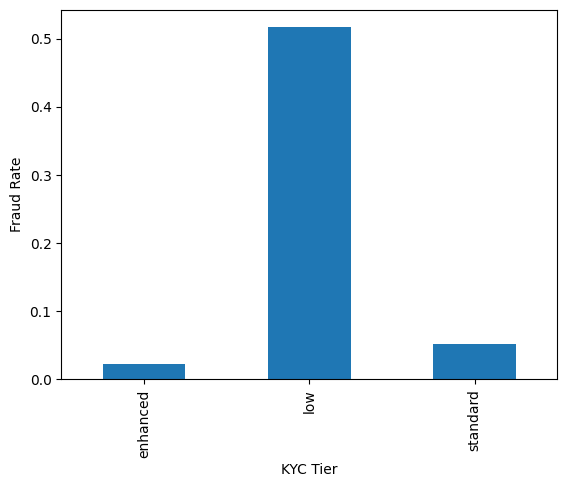

In [166]:
# explore correlation between kyc_tier and the target variable
df.groupby('kyc_tier')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('KYC Tier')
plt.show()

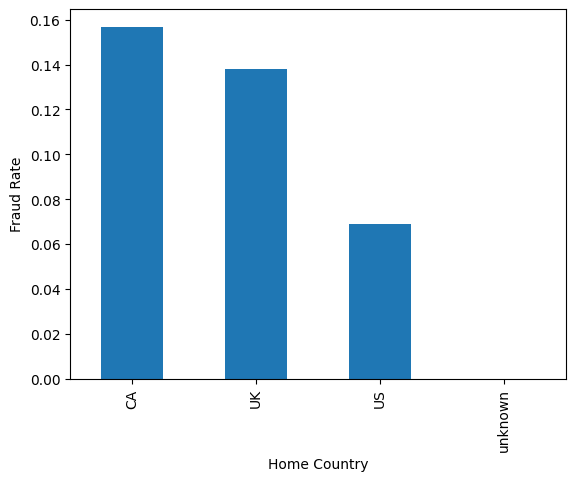

In [167]:
# explore correlation between home_country and the target variable
df.groupby('home_country')['is_fraud'].mean().plot.bar()
plt.ylabel('Fraud Rate')
plt.xlabel('Home Country')
plt.show()

### Feature Engineering

In [168]:
# display timestamp format
df['timestamp'].unique()

<DatetimeArray>
['2022-10-03 18:40:59.468549+00:00', '2022-10-03 20:39:38.468549+00:00',
 '2022-10-03 23:02:43.468549+00:00', '2022-10-04 01:08:53.468549+00:00',
 '2022-10-04 09:35:03.468549+00:00', '2022-10-04 12:09:59.468549+00:00',
 '2022-10-04 12:37:41.468549+00:00', '2022-10-04 16:27:44.468549+00:00',
 '2022-10-04 21:00:36.468549+00:00', '2022-10-04 21:20:42.468549+00:00',
 ...
 '2025-11-24 13:42:17.573611+00:00', '2025-11-25 00:45:10.573611+00:00',
 '2025-11-25 07:44:29.573611+00:00', '2025-11-25 07:56:54.573611+00:00',
 '2025-11-25 09:48:28.573611+00:00', '2025-11-25 10:05:35.573611+00:00',
 '2025-11-26 07:09:56.573611+00:00', '2025-11-27 06:19:11.573611+00:00',
 '2025-11-28 00:53:28.573611+00:00', '2025-11-29 20:10:47.573611+00:00']
Length: 10590, dtype: datetime64[ns, UTC]

In [169]:
# check for invalid timestamps in the dataset
parsed = pd.to_datetime(df['timestamp'], errors='coerce')
invalid_timestamps = df[parsed.isna()]
print(invalid_timestamps[['timestamp']].drop_duplicates())
print("\nCount:", len(invalid_timestamps))


Empty DataFrame
Columns: [timestamp]
Index: []

Count: 0


In [170]:
# from timestamp, extract the hour of the day, day of the week, and weekend indicator
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("Timestamp Features:")
print(df[['timestamp', 'hour_of_day', 'day_of_week', 'is_weekend']].head())
print("\nHour of Day Distribution:")
print(df['hour_of_day'].value_counts())

Timestamp Features:
                         timestamp  hour_of_day  day_of_week  is_weekend
0 2022-10-03 18:40:59.468549+00:00           18            0           0
1 2022-10-03 20:39:38.468549+00:00           20            0           0
2 2022-10-03 23:02:43.468549+00:00           23            0           0
3 2022-10-04 01:08:53.468549+00:00            1            1           0
4 2022-10-04 09:35:03.468549+00:00            9            1           0

Hour of Day Distribution:
hour_of_day
4     503
19    491
3     480
23    477
8     471
5     471
15    467
18    467
6     464
16    461
0     452
22    450
12    447
10    444
13    444
7     439
20    434
9     425
11    424
21    423
17    422
14    413
2     413
1     398
Name: count, dtype: int64



Hourly Fraud Rate:


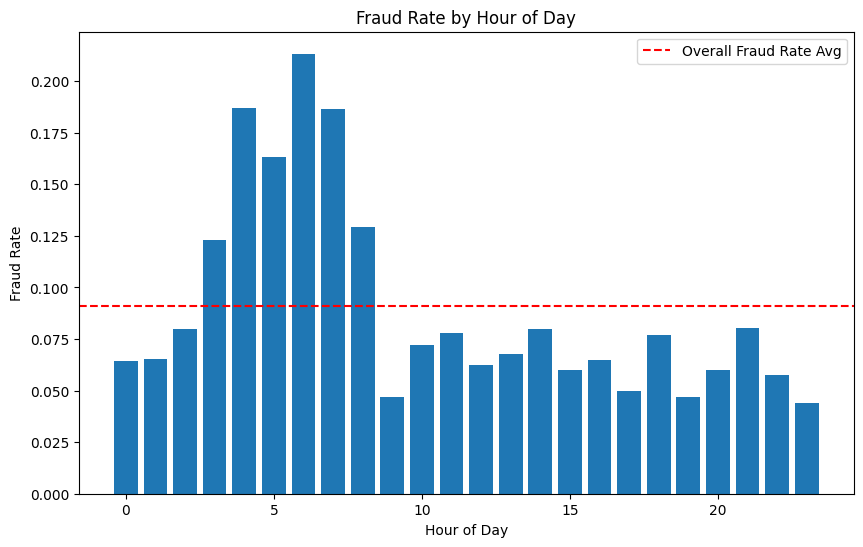

In [171]:
# examine hour and target variable relationship
hourly_fraud_rate = df.groupby('hour_of_day')['is_fraud'].mean()
print("\nHourly Fraud Rate:")

plt.figure(figsize=(10, 6))
plt.bar(hourly_fraud_rate.index, hourly_fraud_rate.values)
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()


Daily Fraud Rate:


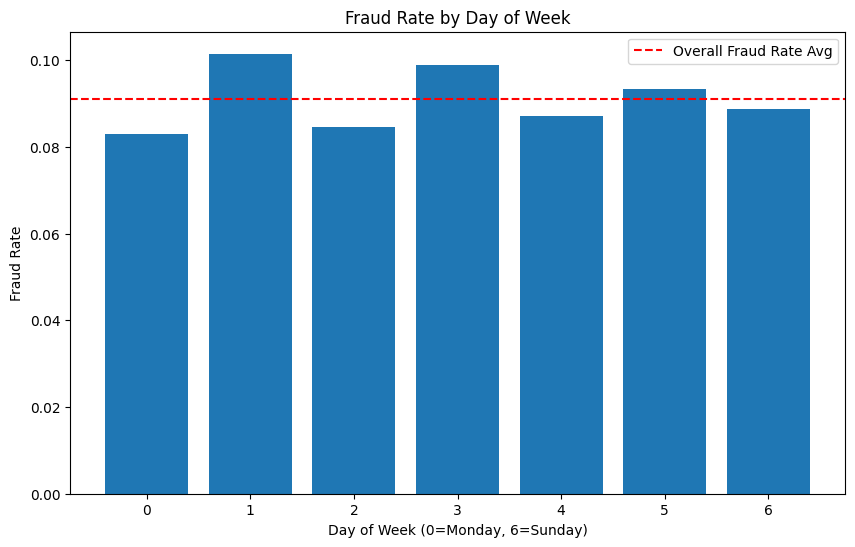

In [172]:
# examnine day of week and target variable relationship
daily_fraud_rate = df.groupby('day_of_week')['is_fraud'].mean()
print("\nDaily Fraud Rate:")
plt.figure(figsize=(10, 6))
plt.bar(daily_fraud_rate.index, daily_fraud_rate.values)
plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Fraud Rate')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

Fraud Rate by Account Age Bucket:
age_bucket
0-30d       0.368681
31-90d      0.442584
91-180d     0.023736
181-365d    0.016901
365+        0.010534
Name: is_fraud, dtype: float64


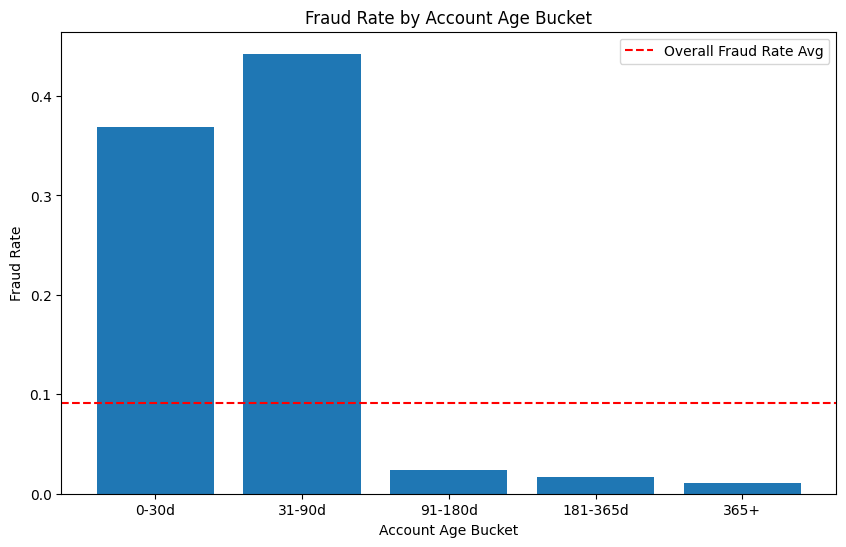

In [173]:
# examine account age and target variable relationship
df['age_bucket'] = pd.cut(df['account_age_days'], bins=[0, 30, 90, 180, 365, 2000], labels=['0-30d', '31-90d', '91-180d', '181-365d', '365+'])

fraud_by_age = df.groupby('age_bucket')['is_fraud'].mean()
print("Fraud Rate by Account Age Bucket:")
print(fraud_by_age)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_age)), fraud_by_age.values)
plt.xticks(range(len(fraud_by_age)), fraud_by_age.index)
plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Account Age Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

In [174]:
df['account_age_days'].describe()

count    10780.00000
mean       393.49898
std        342.17545
min          1.00000
25%        147.00000
50%        285.00000
75%        661.00000
max       1095.00000
Name: account_age_days, dtype: float64

Fraud Rate by Transaction Velocity (1h):
txn_velocity_1h
0    0.017459
1    0.000000
2    0.000000
3    0.835878
4    0.842324
5    0.801047
6    0.700000
7    0.702703
8    0.482759
Name: is_fraud, dtype: float64


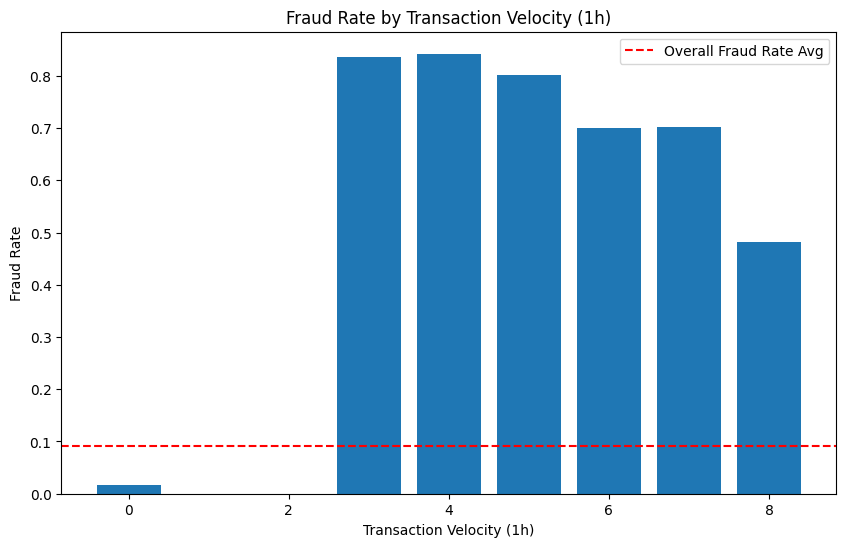

In [175]:
# examine velocity rate and target variable relationship
fraud_by_velocity = df.groupby('txn_velocity_1h')['is_fraud'].mean()
print("Fraud Rate by Transaction Velocity (1h):")
print(fraud_by_velocity)

plt.figure(figsize=(10, 6))
plt.bar(fraud_by_velocity.index, fraud_by_velocity.values)
plt.xlabel('Transaction Velocity (1h)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Transaction Velocity (1h)')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

Fraud Rate by Amount USD Bucket:
amount_usd_bucket
0-10          0.000000
11-50         0.020859
51-100        0.016887
101-500       0.061642
501-1000      0.301768
1001-5000     0.744318
5001-10000    0.136842
10001+        0.166667
Name: is_fraud, dtype: float64


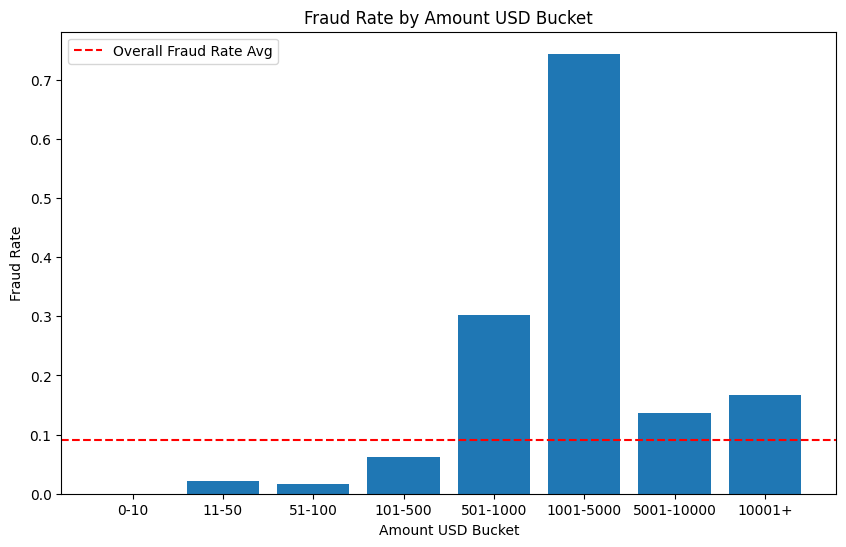

In [176]:
# examine amount_usd and target variable relationship
df['amount_usd_bucket'] = pd.cut(df['amount_usd'], bins=[0, 10, 50, 100, 500, 1000, 5000, 10000, np.inf], labels=['0-10', '11-50', '51-100', '101-500', '501-1000', '1001-5000', '5001-10000', '10001+'])

fraud_by_amount = df.groupby('amount_usd_bucket')['is_fraud'].mean()
print("Fraud Rate by Amount USD Bucket:")
print(fraud_by_amount)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_amount)), fraud_by_amount.values)
plt.xticks(range(len(fraud_by_amount)), fraud_by_amount.index)
plt.xlabel('Amount USD Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Amount USD Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

Fraud Rate by Risk Score Internal Bucket:
risk_score_internal_bucket
0-0.2      0.011902
0.2-0.4    0.037893
0.4-0.6    0.219802
0.6-0.8    1.000000
0.8-1.0    1.000000
Name: is_fraud, dtype: float64


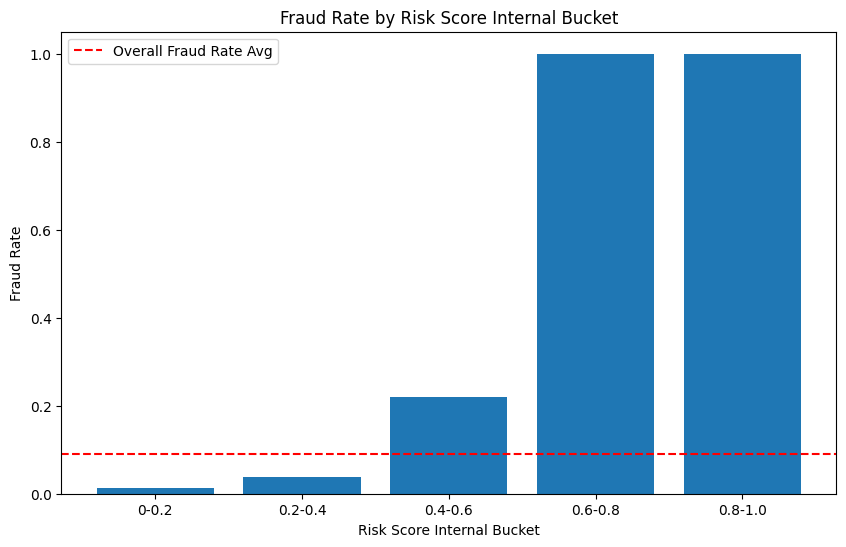

In [177]:
# examine ip risk score and target variable relationship
df['risk_score_internal_bucket'] = pd.cut(df['risk_score_internal'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])

fraud_by_risk_score = df.groupby('risk_score_internal_bucket')['is_fraud'].mean()
print("Fraud Rate by Risk Score Internal Bucket:")
print(fraud_by_risk_score)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_risk_score)), fraud_by_risk_score.values)
plt.xticks(range(len(fraud_by_risk_score)), fraud_by_risk_score.index)
plt.xlabel('Risk Score Internal Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Risk Score Internal Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

Fraud Rate by Device Trust Score Bucket:
device_trust_score_bucket
0-0.2      0.811508
0.2-0.4    0.203959
0.4-0.6    0.040541
0.6-0.8    0.018776
0.8-1.0    0.021694
Name: is_fraud, dtype: float64


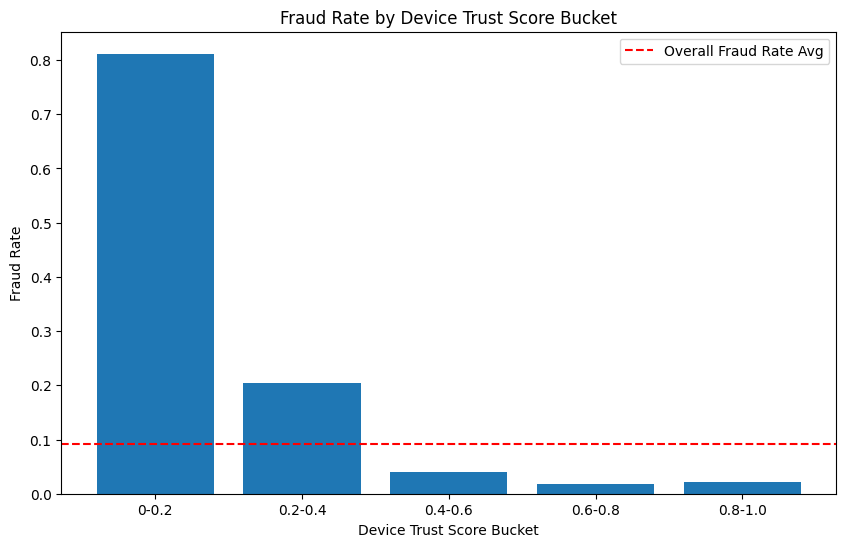

In [178]:
# examine device trust score and target variable relationship
df['device_trust_score_bucket'] = pd.cut(df['device_trust_score'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0'])
fraud_by_device_trust_score = df.groupby('device_trust_score_bucket')['is_fraud'].mean()
print("Fraud Rate by Device Trust Score Bucket:")
print(fraud_by_device_trust_score)

plt.figure(figsize=(10, 6))
plt.bar(range(len(fraud_by_device_trust_score)), fraud_by_device_trust_score.values)
plt.xticks(range(len(fraud_by_device_trust_score)), fraud_by_device_trust_score.index)
plt.xlabel('Device Trust Score Bucket')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Device Trust Score Bucket')
plt.axhline(y=df['is_fraud'].mean(), color='r', linestyle='--', label='Overall Fraud Rate Avg')
plt.legend()
plt.show()

In [179]:
# Based on the EDA, create a threshold-based features
df['night_time_transaction'] = ((df['hour_of_day'] >= 3) & (df['hour_of_day'] <= 8)).astype(int)
df['velocity_high'] = (df['txn_velocity_1h'] >= 3).astype(int)
df['amount_high'] = (df['amount_usd'] >= 500).astype(int)
df['ip_risk_high'] = (df['risk_score_internal'] >= 0.6).astype(int)
df['device_trust_low'] = (df['device_trust_score'] <= 0.4).astype(int)
df['account_age_very_new'] = (df['account_age_days'] <= 30).astype(int)
df['account_age_new'] = (df['account_age_days'] >= 30) & (df['account_age_days'] <= 90).astype(int)

print("New Features Created:")
print(df[['night_time_transaction', 'velocity_high', 'amount_high', 'ip_risk_high', 'device_trust_low', 'account_age_very_new', 'account_age_new']].describe())

New Features Created:


       night_time_transaction  velocity_high   amount_high  ip_risk_high  \
count            10780.000000   10780.000000  10780.000000  10780.000000   
mean                 0.262338       0.098516      0.126531      0.039054   
std                  0.439926       0.298025      0.332462      0.193732   
min                  0.000000       0.000000      0.000000      0.000000   
25%                  0.000000       0.000000      0.000000      0.000000   
50%                  0.000000       0.000000      0.000000      0.000000   
75%                  1.000000       0.000000      0.000000      0.000000   
max                  1.000000       1.000000      1.000000      1.000000   

       device_trust_low  account_age_very_new  
count      10780.000000          10780.000000  
mean           0.201391              0.168831  
std            0.401058              0.374620  
min            0.000000              0.000000  
25%            0.000000              0.000000  
50%            0.000000    

In [180]:
# drop the temporary bucket columns and select final features for modeling
df.drop(['age_bucket', 'amount_usd_bucket', 'risk_score_internal_bucket', 'device_trust_score_bucket'], axis=1)

# define the features
categorical_features = ['home_country', 'source_currency', 'channel', 
                        'dest_currency', 'kyc_tier', 'ip_country', 
                        'location_mismatch', 'new_device']

numeric_features = ['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 
                    'device_trust_score', 'txn_velocity_1h', 'txn_velocity_24h', 
                    'risk_score_internal', 'corridor_risk', 'account_age_days', 'hour_of_day', 'day_of_week',
                    'is_weekend', 'night_time_transaction', 'velocity_high',
                    'amount_high', 'ip_risk_high', 'device_trust_low',
                    'account_age_very_new', 'account_age_new']

all_features = categorical_features + numeric_features

print(f"total features: {len(all_features)}")
print(f"categorical features: {len(categorical_features)}")
print(f"numeric features: {len(numeric_features)}")
print(f"Dataset shape: {df.shape}")

total features: 28
categorical features: 8
numeric features: 20
Dataset shape: (10780, 40)


In [181]:
# display all columns headers
df.columns.tolist()

['transaction_id',
 'customer_id',
 'timestamp',
 'home_country',
 'source_currency',
 'dest_currency',
 'channel',
 'amount_src',
 'amount_usd',
 'fee',
 'exchange_rate_src_to_dest',
 'device_id',
 'new_device',
 'ip_address',
 'ip_country',
 'location_mismatch',
 'ip_risk_score',
 'kyc_tier',
 'account_age_days',
 'device_trust_score',
 'chargeback_history_count',
 'risk_score_internal',
 'txn_velocity_1h',
 'txn_velocity_24h',
 'corridor_risk',
 'is_fraud',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'age_bucket',
 'amount_usd_bucket',
 'risk_score_internal_bucket',
 'device_trust_score_bucket',
 'night_time_transaction',
 'velocity_high',
 'amount_high',
 'ip_risk_high',
 'device_trust_low',
 'account_age_very_new',
 'account_age_new']

### Modelling

In [182]:
# Sort by timestamp to ensure the data is in chronological order
df = df.sort_values('timestamp').reset_index(drop=True)

# 80/20 split
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print(f"Train: {len(train_df)} rows ({train_df['is_fraud'].sum()} fraud, {train_df['is_fraud'].mean():.3f} rate)")
print(f"Test: {len(test_df)} rows ({test_df['is_fraud'].sum()} fraud, {test_df['is_fraud'].mean():.3f} rate)")

# Prepare X and y for training and testing
X_train = train_df[all_features]
y_train = train_df['is_fraud']
X_test = test_df[all_features]
y_test = test_df['is_fraud']

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Train: 8624 rows (673 fraud, 0.078 rate)
Test: 2156 rows (308 fraud, 0.143 rate)

X_train shape: (8624, 28), y_train shape: (8624,)
X_test shape: (2156, 28), y_test shape: (2156,)


In [183]:
# import one-hot encoder for categorical features and standard scaler for numeric features
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# build a preprocessing pipeline for categorical and numeric features
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# fit the preprocessor on the training data and transform both training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Original features: {len(all_features)} After one-hot encoding, the number of features increased to: {X_train_processed.shape[1]}")

Processed X_train shape: (8624, 45)
Original features: 28 After one-hot encoding, the number of features increased to: 45


In [184]:
# Baseline model: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve

# Train a logistic regression model with balanced class weights to handle class imbalance
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_processed, y_train)

# Predict on the test set
y_pred_lr = logreg.predict(X_test_processed)
y_pred_proba_lr = logreg.predict_proba(X_test_processed)[:, 1]

# Evaluate the model
print("Logistic Regression Results:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

Logistic Regression Results:
Confusion Matrix:
[[1778   70]
 [  16  292]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.96      0.98      1848
       Fraud       0.81      0.95      0.87       308

    accuracy                           0.96      2156
   macro avg       0.90      0.96      0.92      2156
weighted avg       0.96      0.96      0.96      2156

ROC AUC Score: 0.9827


### Logistic Regression Interpretation
- Missed frauds = 16 i.e model catches 292 out of 308 frauds. 
- False alarms = 70 legitimate transactions flagged as fraud.
- Model finds most frauds (95% high recall), but 19% of its fraud alerts are false alarms (81% precision), giving an F1-score of 87%.
- ROC AUC 98% confirms the model separates classes well

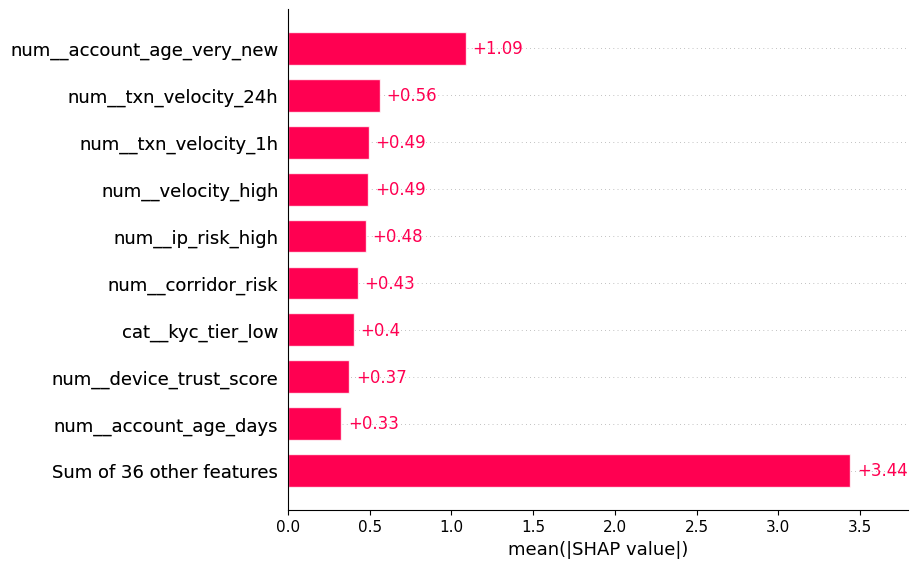

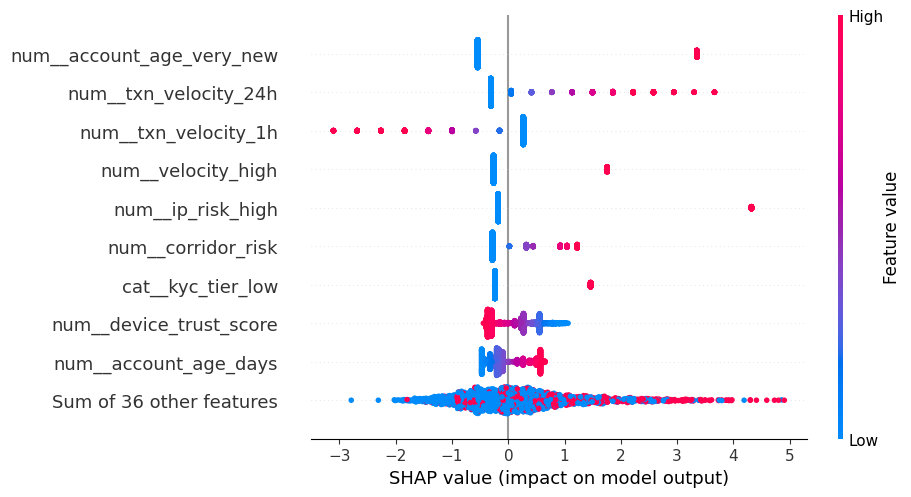

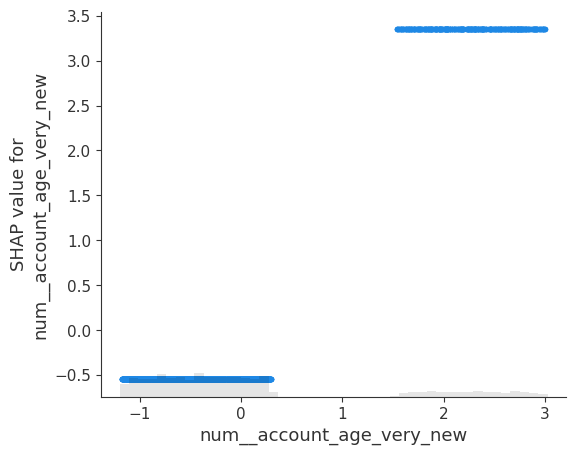

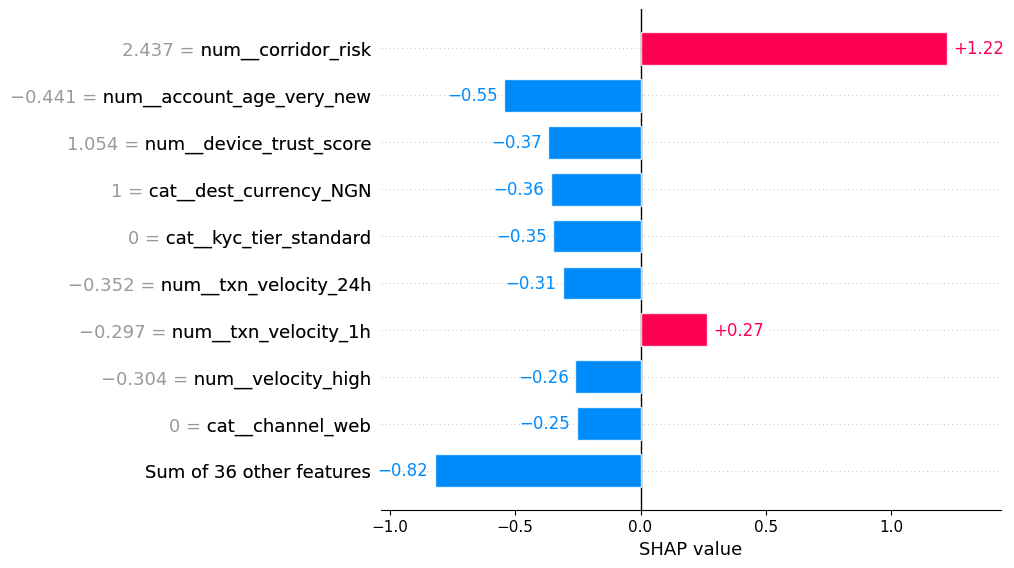

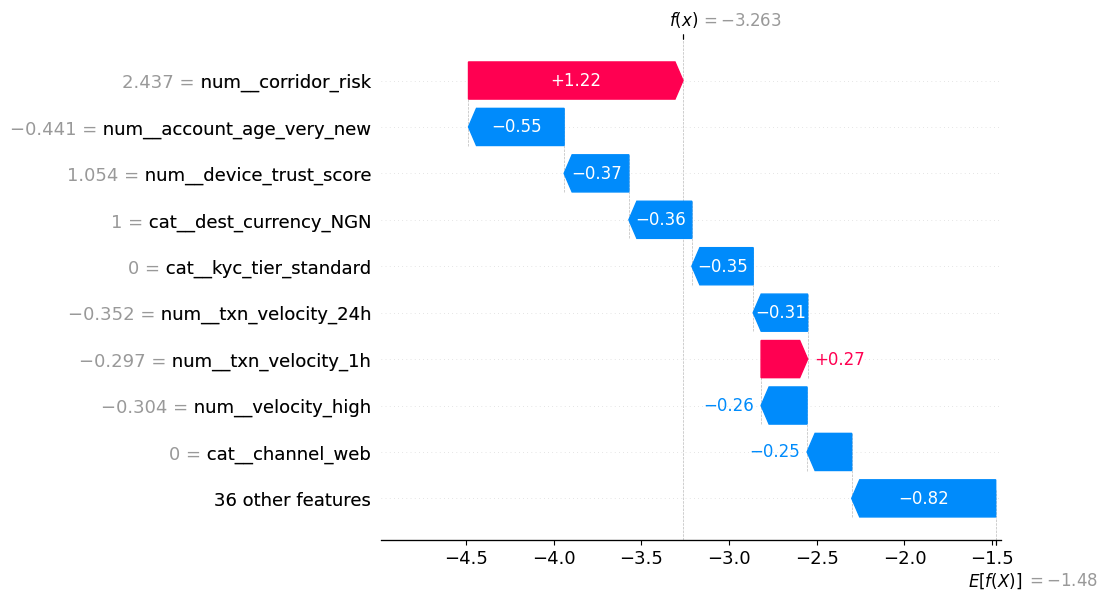

(2156, 45)


In [185]:

# Feature names after preprocessing
feature_names_lr = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names_lr)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names_lr)

# SHAP explainer for Logistic Regression
explainer = shap.Explainer(logreg, X_train_df)

# Compute SHAP values
shap_values_lr = explainer(X_test_df)

# 1. Global feature importance
shap.plots.bar(shap_values_lr)

# 2. Beeswarm plot
shap.plots.beeswarm(shap_values_lr)

# 3. Dependence / scatter plot for most important feature
top_feature_lr = shap_values_lr.abs.mean(0).values.argmax()
shap.plots.scatter(shap_values_lr[:, top_feature_lr])

# 4. Individual feature importance for one prediction
i = 0
shap.plots.bar(shap_values_lr[i])

# 5. Waterfall plot for one prediction
shap.plots.waterfall(shap_values_lr[i])

print(X_test_df.shape)

Summary

Top Risk Drivers: New accounts (account_age_very_new), high transaction velocity (1h & 24h), high IP/corridor risk these most strongly raise the model’s fraud score.
Protective Signals: High device_trust_score and completed KYC (kyc_tier_standard) lower fraud probability.
Behavioral Pattern: Combinations matter, e.g., a very-new account + high velocity + high corridor risk produces the strongest fraud signals.

What the Plots Tell Us

Bar plot: Ranks which features matter most overall, new accounts are top.
Beeswarm: Shows how feature values change risk, red (high) for velocity and risk flags pushes predictions up; red (high) for device trust pushes predictions down.
Dependence plot: Confirms the effect of a single feature e.g., “very new” accounts clearly increase risk compared with older accounts.
Waterfall (single-transaction): Breaks down one decision: it shows which features increased or decreased the model’s score and by how much, making each decision explainable.

The model identifies fraud risk mainly through account age, transaction speed, IP risk, corridor risk, KYC tier, and device trust. Very new accounts and high transaction velocity are the strongest global fraud indicators. Risky corridors and high-risk IPs also push predictions toward fraud, while stronger device trust and standard KYC signals tend to reduce fraud risk. For the individual case shown, corridor risk increased the fraud score, but the overall combination of other signals reduced the final fraud prediction.

Business implications

Actionable rule suggestions: Consider higher scrutiny or temporary holds for transactions matching: new account AND high velocity AND corridor/IP risk.
Reduce false positives: Use device_trust_score and stronger KYC to lower unnecessary declines, these reliably reduce fraud score.
Investigations & monitoring: Prioritize monitoring of account-newness and velocity trends by corridor; track performance over time.

In [186]:
# Baseline model: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest Classifier with balanced class weights
rf_clf = RandomForestClassifier(
  class_weight='balanced', 
  n_estimators=100, 
  max_depth=10,
  random_state=42,
  n_jobs=-1)
rf_clf.fit(X_train_processed, y_train)

# Predict on the test set
y_pred_rf = rf_clf.predict(X_test_processed)
y_pred_proba_rf = rf_clf.predict_proba(X_test_processed)[:, 1]

# Evaluate the Random Forest model
print("Random Forest Classifier Results:")
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Legit", "Fraud"]))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")


Random Forest Classifier Results:
confusion_matrix:
[[1848    0]
 [  25  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      1848
       Fraud       1.00      0.92      0.96       308

    accuracy                           0.99      2156
   macro avg       0.99      0.96      0.98      2156
weighted avg       0.99      0.99      0.99      2156


ROC AUC Score: 0.9734


### Random Forest Interpretation
- Missed frauds: 25 i.e. model catches 283 out of 308 frauds.
- False alarms: 0 legitimate transactions flagged as fraud (perfect precision).
- Very high precision (100%) and strong recall (92%) giving an F1-score of 96%. few missed frauds and no false positive.
- ROC AUC 97% : model separates classes very well.

100%|===================| 4310/4312 [00:46<00:00]        

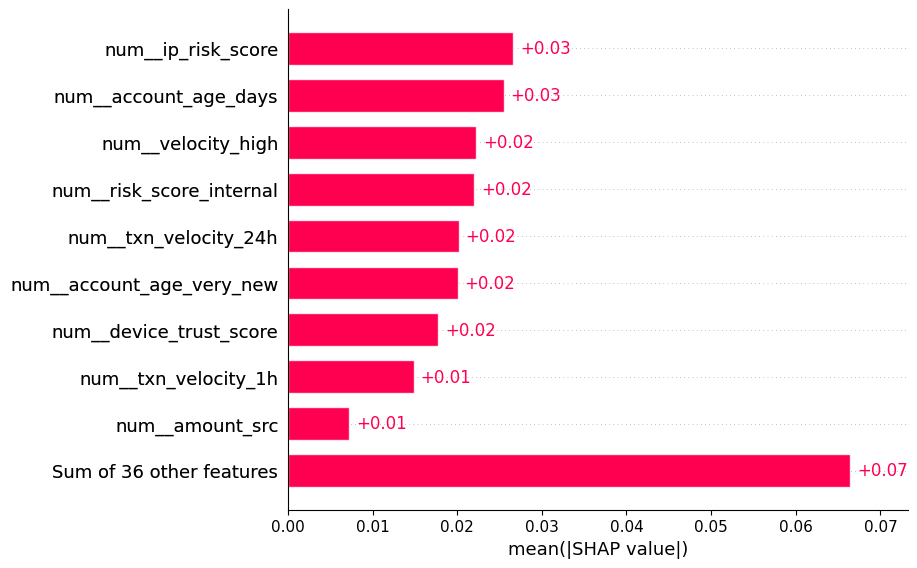

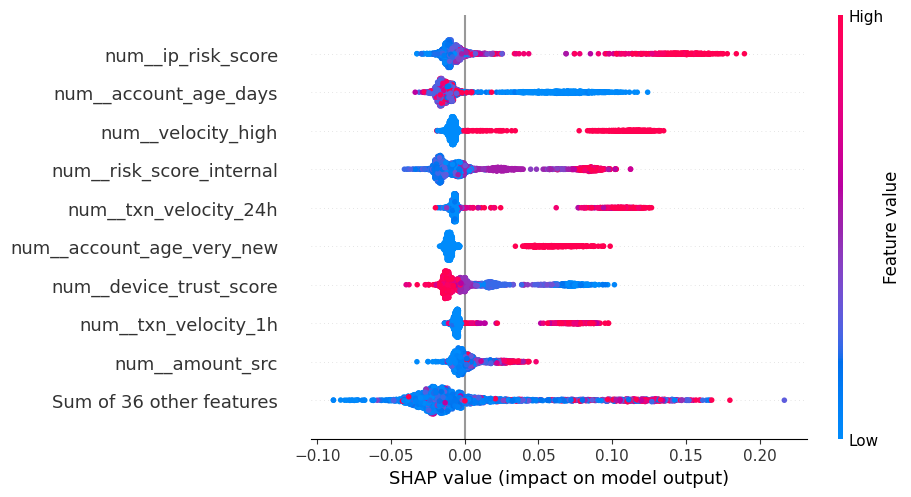

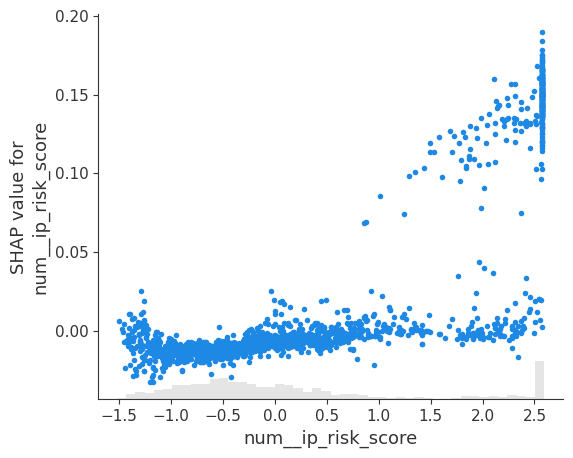

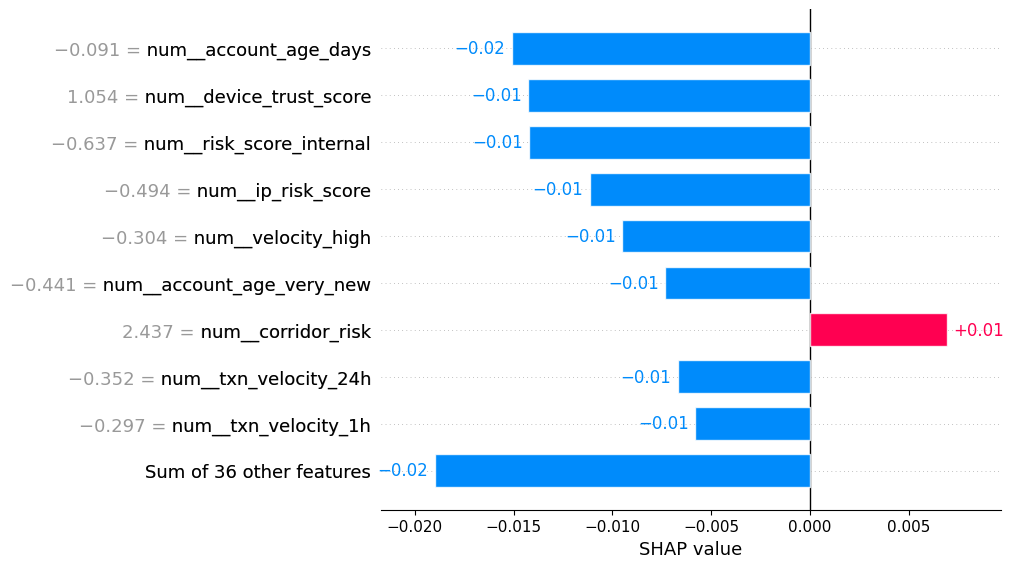

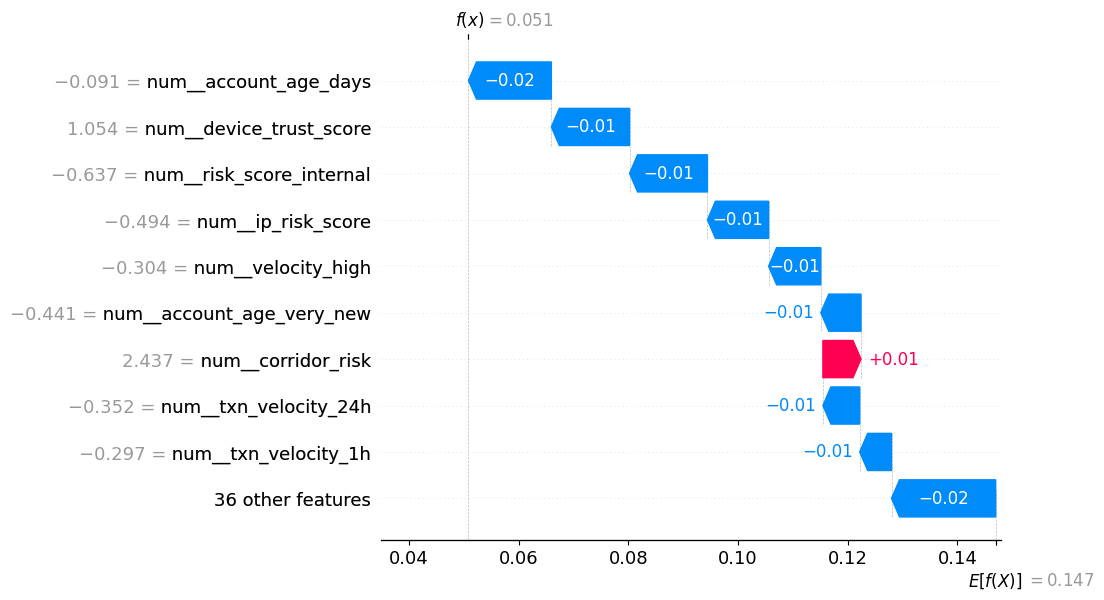

(2156, 45)


In [187]:
# Feature names after preprocessing
feature_names_rf = preprocessor.get_feature_names_out()

X_train_df_rf = pd.DataFrame(X_train_processed, columns=feature_names_rf)
X_test_df_rf = pd.DataFrame(X_test_processed, columns=feature_names_rf)

# SHAP explainer for Random Forest
explainer_rf = shap.Explainer(rf_clf, X_train_df_rf)

# compute SHAP values
shap_values_rf = explainer_rf(X_test_df_rf, check_additivity=False)

# if SHAP returns values for both classes, select positive class: Fraud
if len(shap_values_rf.values.shape) == 3:
  shap_values_rf_fraud = shap_values_rf[:, :, 1]
else:
  shap_values_rf_fraud = shap_values_rf

# 1. Global feature importance
shap.plots.bar(shap_values_rf_fraud)

# 2. Beeswarm plot
shap.plots.beeswarm(shap_values_rf_fraud)

# 3. Dependence / Scatter plot for most important feature
top_feature_rf = shap_values_rf_fraud.abs.mean(0).values.argmax()
shap.plots.scatter(shap_values_rf_fraud[:, top_feature_rf])
                   
# 4. Individual feature importance for one prediction
i = 0
shap.plots.bar(shap_values_rf_fraud[i])

# 5. Waterfall plot for one prediction
shap.plots.waterfall(shap_values_rf_fraud[i])

print(X_test_df_rf.shape)

The Random Forest model mainly identifies fraud through IP risk, account age, transaction velocity, internal risk score, very new account status, and device trust. High IP risk, fast transaction activity, newer accounts, and high internal risk scores increase the likelihood of fraud. Stronger device trust and older account history reduce fraud risk. For the individual case shown, the model found mostly low-risk signals, so the final fraud score was below the model’s average, with only corridor risk adding a small amount of concern.


In [188]:
# Advanced regression : XGBOOST
from xgboost import XGBClassifier

# calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train XGBoost
xgb_model = XGBClassifier(
  n_estimators = 100,
  max_depth = 6,
  learning_rate = 0.1,
  scale_pos_weight = scale_pos_weight,
  random_state = 42,
  eval_metric = 'logloss'
)
xgb_model.fit(X_train_processed, y_train)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test_processed)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation of Model
print("XBGoost Results:")
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=["Legit", "Fraud"]))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")


XBGoost Results:
confusion_matrix:
[[1828   20]
 [  25  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      1848
       Fraud       0.93      0.92      0.93       308

    accuracy                           0.98      2156
   macro avg       0.96      0.95      0.96      2156
weighted avg       0.98      0.98      0.98      2156


ROC AUC Score: 0.9705


### XGBoost Regression Interpretation
- Missed frauds: 25 i.e model catches 283 out of 308 frauds
- False alarms: 20 legitimate transactions flagged as fraud
- Fraud precision (93%), recall (92%), and F1-score (93%) gives a good balance with modest false positive and strong detection.
- ROC AUC 97% : model separates classes very well.

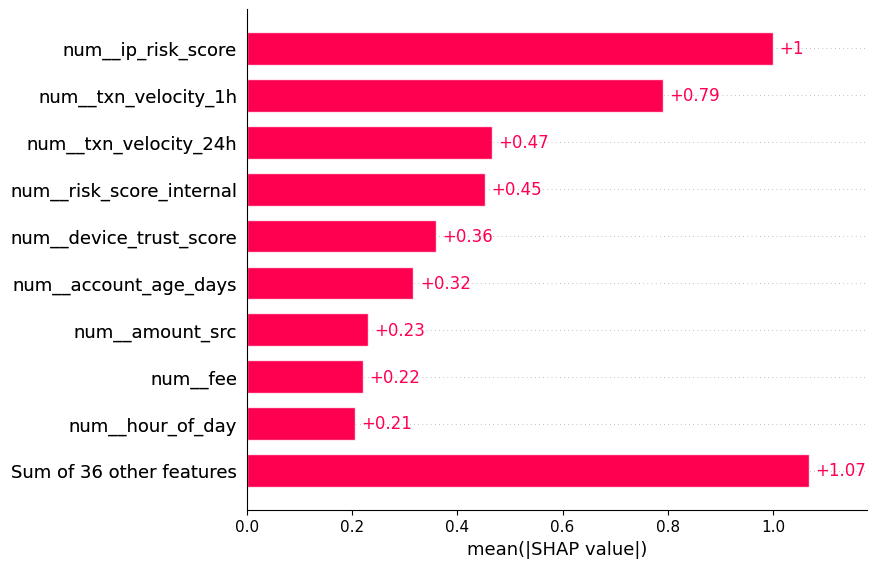

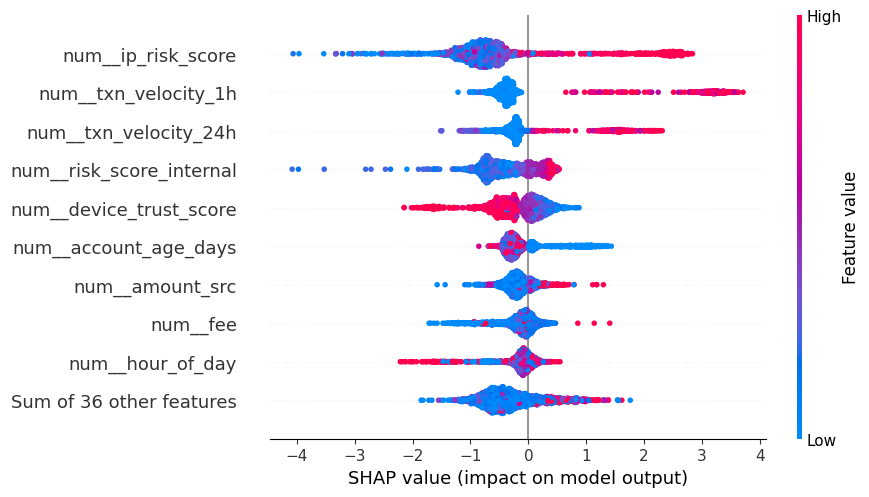

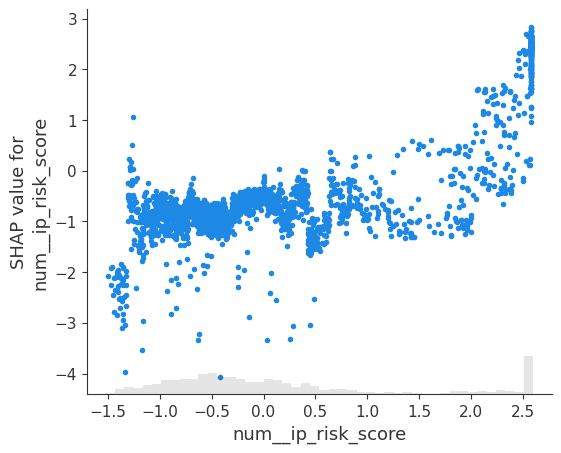

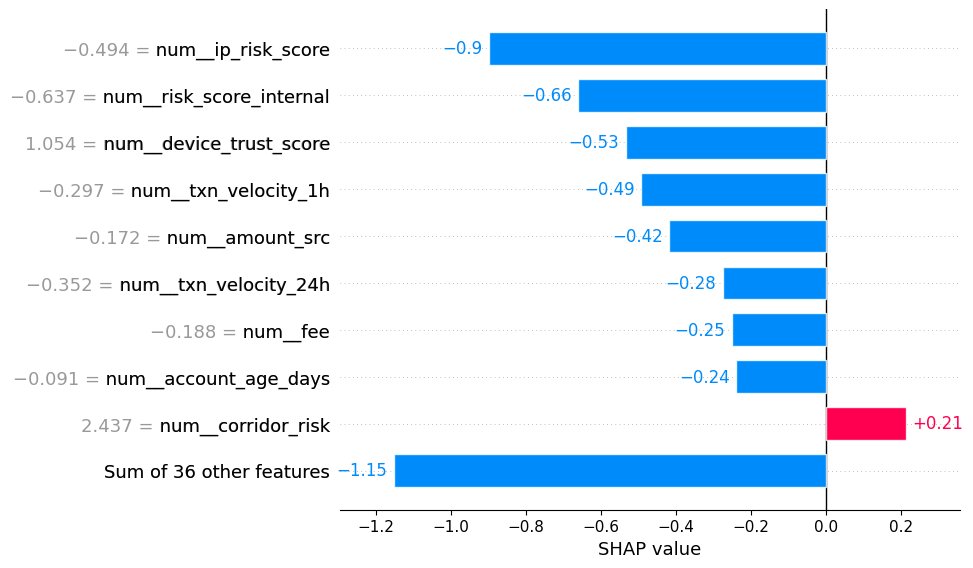

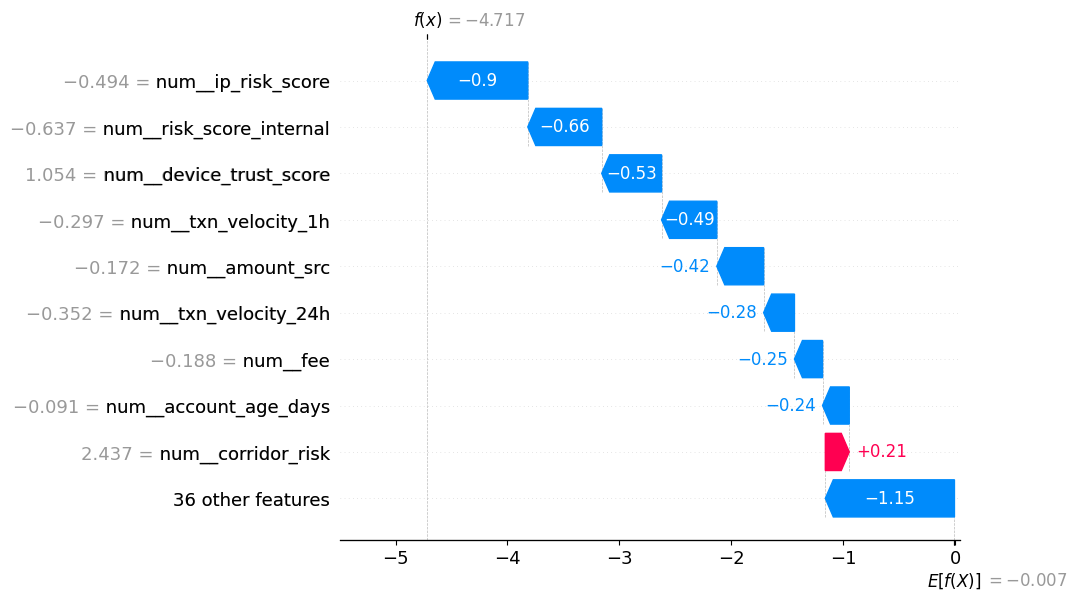

(2156, 45)


In [189]:
import shap
import xgboost as xgb

# Feature names after preprocessing
feature_names_xgb = preprocessor.get_feature_names_out()

X_test_df_xgb = pd.DataFrame(X_test_processed, columns=feature_names_xgb)

# Convert test data to XGBoost DMatrix
dtest_xgb = xgb.DMatrix(X_test_df_xgb, feature_names=list(feature_names_xgb))

# XGBoost built-in SHAP values
# Last column is the base value
shap_contribs_xgb = xgb_model.get_booster().predict(
    dtest_xgb,
    pred_contribs=True
)

# Split SHAP values and base values
shap_values_xgb_array = shap_contribs_xgb[:, :-1]
base_values_xgb = shap_contribs_xgb[:, -1]

# Convert to SHAP Explanation object
shap_values_xgb = shap.Explanation(
    values=shap_values_xgb_array,
    base_values=base_values_xgb,
    data=X_test_df_xgb.values,
    feature_names=feature_names_xgb
)

# 1. Global feature importance
shap.plots.bar(shap_values_xgb)

# 2. Beeswarm plot
shap.plots.beeswarm(shap_values_xgb)

# 3. Dependence / scatter plot for most important feature
top_feature_xgb = shap_values_xgb.abs.mean(0).values.argmax()
shap.plots.scatter(shap_values_xgb[:, top_feature_xgb])

# 4. Individual feature importance for one prediction
i = 0
shap.plots.bar(shap_values_xgb[i])

# 5. Waterfall plot for one prediction
shap.plots.waterfall(shap_values_xgb[i])

print(X_test_df_xgb.shape)

The XGBoost model identifies fraud mainly through IP risk, transaction velocity, internal risk score, and device trust. High-risk IPs and rapid transaction activity are the strongest warning signs, while trusted devices and lower-risk behavioral patterns reduce fraud likelihood. For the individual example shown, most signals pointed away from fraud, with only corridor risk adding a small concern, so the model treated the case as low risk overall.

In [190]:
# Advanced regression : LightGBM
from lightgbm import LGBMClassifier

# Train LGBM
lgbm_model = LGBMClassifier(
  n_estimators = 100,
  max_depth = 6,
  learning_rate = 0.1,
  class_weight= 'balanced',
  random_state = 42,
  verbosity = -1
)
lgbm_model.fit(X_train_processed, y_train)

# Predict on the test set
y_pred_lgbm = lgbm_model.predict(X_test_processed)
y_pred_proba_lgbm = lgbm_model.predict_proba(X_test_processed)[:, 1]

# Evaluation of Model
print("LightGBM Results:")
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=["Legit", "Fraud"]))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lgbm):.4f}")


LightGBM Results:
confusion_matrix:
[[1821   27]
 [  25  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      1848
       Fraud       0.91      0.92      0.92       308

    accuracy                           0.98      2156
   macro avg       0.95      0.95      0.95      2156
weighted avg       0.98      0.98      0.98      2156


ROC AUC Score: 0.9677


### LightGBM
- Missed frauds: 25 i.e. model catches 283 out of 308 frauds.
- False alarms: 27 legitimate transactions flagged as fraud.
- Fraud precision (91%), recall (92%), F1 (92%) good detection with modest false positives.
ROC AUC: (96.77%) : model separates classes very well overall.

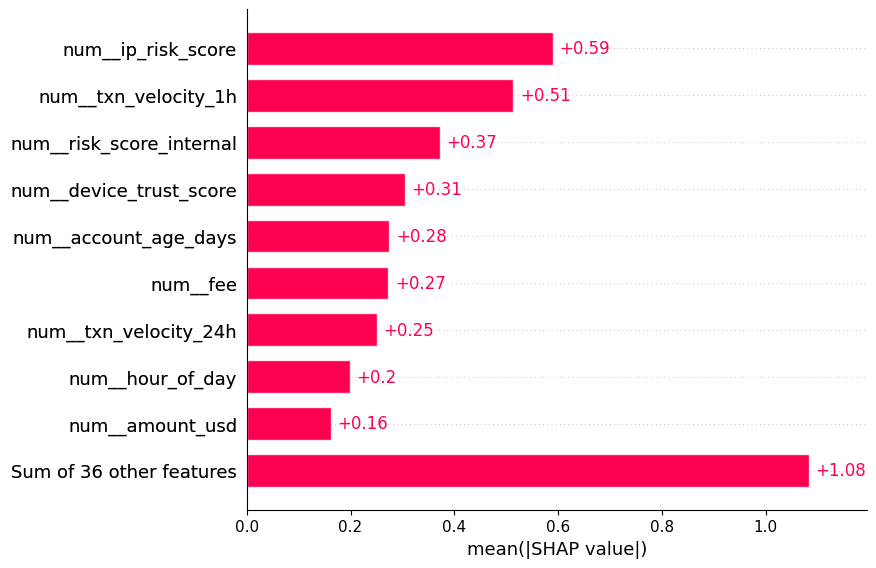

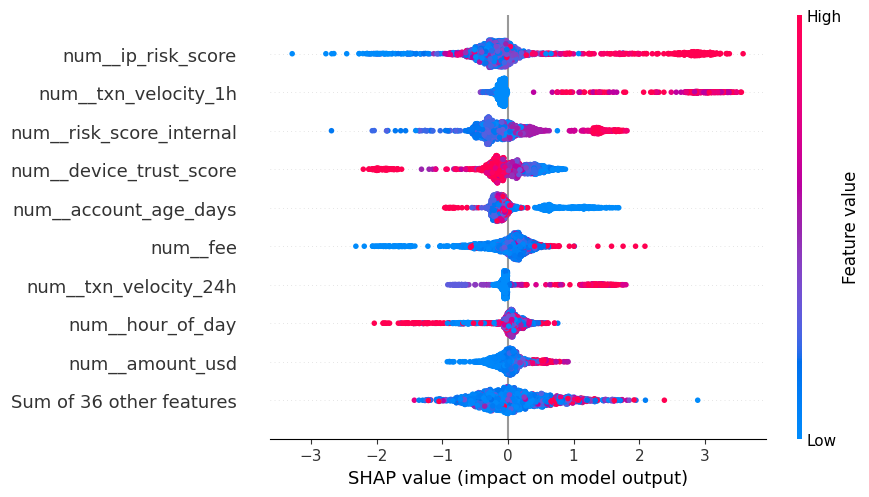

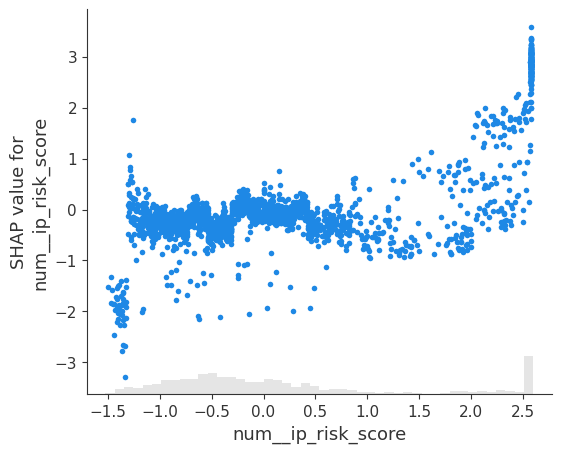

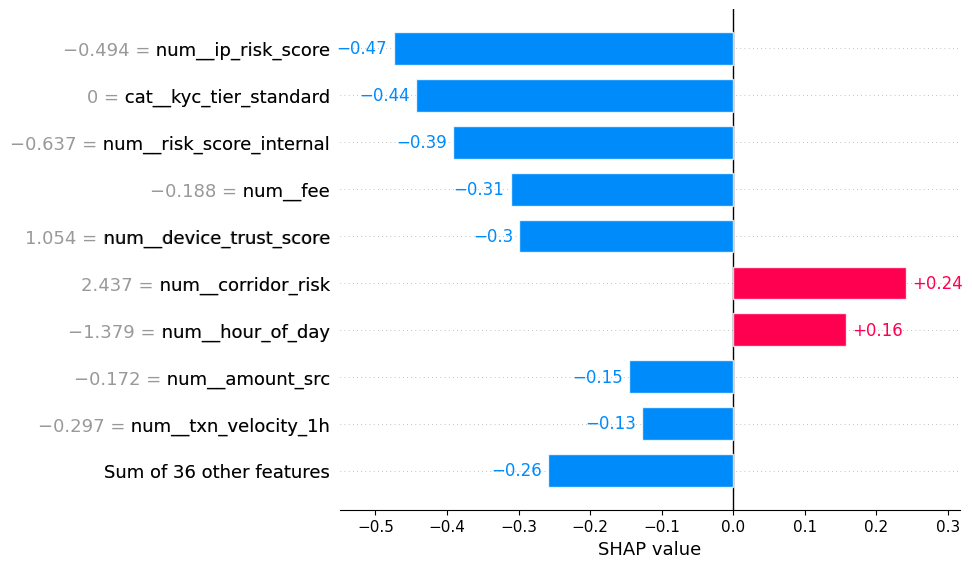

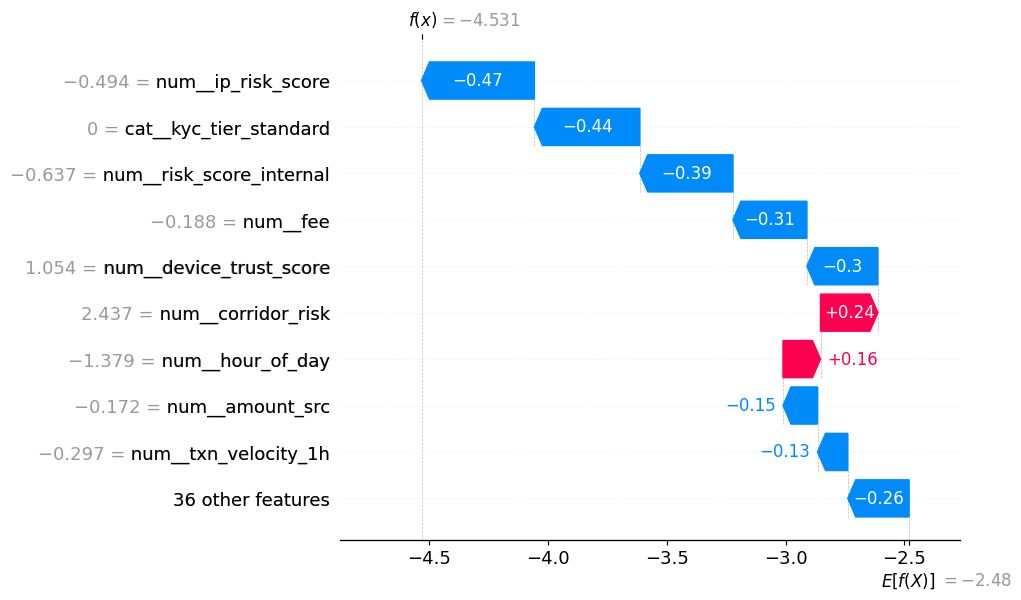

(2156, 45)


In [191]:

# Feature names after preprocessing
feature_names_lgbm = preprocessor.get_feature_names_out()

X_train_df_lgbm = pd.DataFrame(X_train_processed, columns=feature_names_lgbm)
X_test_df_lgbm = pd.DataFrame(X_test_processed, columns=feature_names_lgbm)

# SHAP TreeExplainer for LightGBM
explainer_lgbm = shap.TreeExplainer(lgbm_model)

# Compute SHAP values
shap_values_lgbm_array = explainer_lgbm.shap_values(X_test_df_lgbm)

# For binary classification, LightGBM may return a list: [Legit, Fraud]
if isinstance(shap_values_lgbm_array, list):
    shap_values_lgbm_array = shap_values_lgbm_array[1]

# Base value for Fraud class
base_value_lgbm = explainer_lgbm.expected_value
if isinstance(base_value_lgbm, list):
    base_value_lgbm = base_value_lgbm[1]

# Convert to SHAP Explanation object so modern plots work
shap_values_lgbm = shap.Explanation(
    values=shap_values_lgbm_array,
    base_values=base_value_lgbm,
    data=X_test_df_lgbm.values,
    feature_names=feature_names_lgbm
)

# 1. Global feature importance
shap.plots.bar(shap_values_lgbm)

# 2. Beeswarm plot
shap.plots.beeswarm(shap_values_lgbm)

# 3. Dependence / scatter plot for most important feature
top_feature_lgbm = shap_values_lgbm.abs.mean(0).values.argmax()
shap.plots.scatter(shap_values_lgbm[:, top_feature_lgbm])

# 4. Individual feature importance for one prediction
i = 0
shap.plots.bar(shap_values_lgbm[i])

# 5. Waterfall plot for one prediction
shap.plots.waterfall(shap_values_lgbm[i])

print(X_test_df_lgbm.shape)

The model’s main fraud signals are IP risk score, 1-hour transaction velocity, internal risk score, device trust, and account age.
High IP risk, fast transaction activity, and high internal risk push predictions toward Fraud. Strong device trust, standard KYC, and lower-risk behavior push predictions toward Legit.
For the individual case shown, most signals reduced fraud risk, so the model treated it as low risk, with only corridor risk and hour of day adding slight concern.

### Regression Evaluation
- Logistic Regression: recall 95% (FN=16), precision 81% (FP=70), ROC AUC ≈98% — best at finding frauds (fewest missed) and highest ROC AUC.
- Random Forest: recall 92% (FN=25), precision 100% (FP=0), ROC AUC ≈97.3% — best at avoiding false positives (no false alarms), strong F1.
- XGBoost: recall 92%, precision 93%, ROC AUC 97.05% — good balance between precision and recall.
- LightGBM: recall 92%, precision 91%, ROC AUC 96.77% — similar to XGBoost, slightly lower ROC AUC.

- Based on the results, we will proceed with the Random Forest Classifier and tune its hyperparameters.

In [192]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
import pandas as pd

def summarize_model(name, y_true, y_pred, y_proba=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    summary = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }
    if y_proba is not None:
        summary["roc_auc"] = roc_auc_score(y_true, y_proba)
    else:
        summary["roc_auc"] = None
    return summary

results = [
    summarize_model("Logistic Regression", y_test, y_pred_lr, y_pred_proba_lr),
    summarize_model("Random Forest", y_test, y_pred_rf, y_pred_proba_rf),
    summarize_model("XGBoost", y_test, y_pred_xgb, y_pred_proba_xgb),
    summarize_model("LightGBM", y_test, y_pred_lgbm, y_pred_proba_lgbm),
]

compare_df = pd.DataFrame(results).set_index("model")
compare_df = compare_df[
    ["accuracy", "precision", "recall", "f1", "roc_auc", "tn", "fp", "fn", "tp"]
]
display(compare_df)

,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
model,,,,,,,,,
Logistic Regression,0.960111,0.806630,0.948052,0.871642,0.982700,1778,70,16,292
Random Forest,0.988404,1.000000,0.918831,0.957699,0.973365,1848,0,25,283
XGBoost,0.979128,0.933993,0.918831,0.926350,0.970546,1828,20,25,283
LightGBM,0.975881,0.912903,0.918831,0.915858,0.967666,1821,27,25,283


### Hyper-parameter Tuning

### SMOTE

In [196]:
# apply SMOTE to eliminate imbalance in "is_fraud"

from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the training data
print("Original train class balance")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print("\nAfter SMOTE class balance")
print(y_train_resampled.value_counts())


Original train class balance
is_fraud
0    7951
1     673
Name: count, dtype: int64

After SMOTE class balance
is_fraud
0    7951
1    7951
Name: count, dtype: int64


In [202]:
# XGBoost on SMOTE-balanced training data

# Train XGBoost
xgb_smote_model = XGBClassifier(
  n_estimators = 100,
  max_depth = 6,
  learning_rate = 0.1,
  scale_pos_weight = scale_pos_weight,
  random_state = 42,
  eval_metric = 'logloss'
)
xgb_smote_model.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred_xgb_smote = xgb_smote_model.predict(X_test_processed)
y_pred_proba_xgb_smote = xgb_smote_model.predict_proba(X_test_processed)[:, 1]

# Evaluation of Model
print("XBGoost with SMOTE Results:")
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_xgb_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_smote, target_names=["Legit", "Fraud"]))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb_smote):.4f}")

XBGoost with SMOTE Results:
confusion_matrix:
[[1792   56]
 [  23  285]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.97      0.98      1848
       Fraud       0.84      0.93      0.88       308

    accuracy                           0.96      2156
   macro avg       0.91      0.95      0.93      2156
weighted avg       0.97      0.96      0.96      2156


ROC AUC Score: 0.9688


In [204]:
# Hyperparameter tuning on XGBoost
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter search
xgb_param_dist = {
  "n_estimators": [100, 200, 300],
  "max_deepth": [3, 4, 5, 6, 8],
  "learning_rate": [0.01, 0.05, 0.1, 0.2],
  "subsample": [0.7, 0.8, 1.0],
  "colsample_bytree": [0.7, 0.8, 1.0],
  "min_child_weight": [1, 3, 5],
  "gamma": [0, 0.1, 0.2],
  "reg_alpha": [0, 0.01, 0.1],
  "reg_lambda": [1, 1.5, 2]
}

# Randomize search on SMOTE-balanced training data
xgb_random_search = RandomizedSearchCV(
  estimator=xgb_smote_model,
  param_distributions=xgb_param_dist,
  n_iter=30,
  scoring="f1",
  cv=3,
  verbose=1,
  random_state=42,
  n_jobs=-1
)

xgb_random_search.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(xgb_random_search.best_params_)

print("\nBest CV F1 score")
print(xgb_random_search.best_score_)

# Best tuned model
xgb_tuned_smote_model = xgb_random_search.best_estimator_

# Predict on original test set
y_pred_xgb_tuned = xgb_tuned_smote_model.predict(X_test_processed)
y_pred_proba_xgb_tuned = xgb_tuned_smote_model.predict_proba(X_test_processed)[:, 1]

# Evaluation of Model
print("\nXBGoost Tuned Results:")
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=["Legit", "Fraud"]))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb_tuned):.4f}")


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_deepth': 3, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}

Best CV F1 score
0.9861970300893912

XBGoost Tuned Results:
confusion_matrix:
[[1834   14]
 [  25  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      1848
       Fraud       0.95      0.92      0.94       308

    accuracy                           0.98      2156
   macro avg       0.97      0.96      0.96      2156
weighted avg       0.98      0.98      0.98      2156


ROC AUC Score: 0.9701


#### XGBoost Summary
Before SMOTE, XGBoost performed strongly with 93% fraud precision, 92% fraud recall, 93% F1-score, and 97.05% ROC AUC. After SMOTE, fraud recall improved slightly to 93%, meaning it caught more fraud cases, but precision dropped to 84%, causing more false positives. After hyperparameter tuning, XGBoost improved again with 95% fraud precision, 92% recall, 94% F1-score, and 97.01% ROC AUC, making the tuned version better balanced than the SMOTE-only version.

In [ ]:
# LightGBM  on SMOTE-balanced training data

lgbm_smote_model = LGBMClassifier(
  n_estimators = 100,
  max_depth = 6,
  learning_rate = 0.1,
  class_weight= 'balanced',
  random_state = 42,
  verbosity = -1
)
lgbm_smote_model.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred_lgbm_smote = lgbm_smote_model.predict(X_test_processed)
y_pred_proba_lgbm_smote = lgbm_smote_model.predict_proba(X_test_processed)[:, 1]

# Evaluation of Model
print("LightGBM with SMOTE Results:")
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_lgbm_smote))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm_smote, target_names=["Legit", "Fraud"]))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lgbm_smote):.4f}")

LightGBM with SMOTE Results:
confusion_matrix:
[[1846    2]
 [  25  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      1848
       Fraud       0.99      0.92      0.95       308

    accuracy                           0.99      2156
   macro avg       0.99      0.96      0.97      2156
weighted avg       0.99      0.99      0.99      2156


ROC AUC Score: 0.9737


In [208]:
# Hyperparameter tuning on LightGBM
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter search
lgbm_param_dist = {
  "n_estimators": [100, 200, 300, 500],
  "max_depth": [3, 4, 5, 6, 8, -1],
  "learning_rate": [0.01, 0.05, 0.1, 0.2],
  "num_leaves": [15, 31, 50, 70],
  "subsample": [0.7, 0.8, 1.0],
  "colsample_bytree": [0.7, 0.8, 1.0],
  "min_child_weight": [10, 20, 30, 50],
  "reg_alpha": [0, 0.01, 0.1],
  "reg_lambda": [0, 0.01, 0.1, 1]
}

# Randomize search on SMOTE-balanced training data
lgbm_random_search = RandomizedSearchCV(
  estimator=lgbm_smote_model,
  param_distributions=lgbm_param_dist,
  n_iter=30,
  scoring="f1",
  cv=3,
  verbose=1,
  random_state=42,
  n_jobs=1
)

lgbm_random_search.fit(X_train_resampled, y_train_resampled)

print("Best Parameters:")
print(lgbm_random_search.best_params_)

print("\nBest CV F1 score")
print(lgbm_random_search.best_score_)

# Best tuned model
lgbm_tuned_smote_model = lgbm_random_search.best_estimator_

# Predict on original test set
y_pred_lgbm_tuned = lgbm_tuned_smote_model.predict(X_test_processed)
y_pred_proba_lgbm_tuned = lgbm_tuned_smote_model.predict_proba(X_test_processed)[:, 1]

# Evaluation of Model
print("\nLightGBM Tuned Results:")
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_lgbm_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm_tuned, target_names=["Legit", "Fraud"]))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba_lgbm_tuned):.4f}")


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0.01, 'num_leaves': 15, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Best CV F1 score
0.9864043637104293

LightGBM Tuned Results:
confusion_matrix:
[[1848    0]
 [  25  283]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      1848
       Fraud       1.00      0.92      0.96       308

    accuracy                           0.99      2156
   macro avg       0.99      0.96      0.98      2156
weighted avg       0.99      0.99      0.99      2156


ROC AUC Score: 0.9790


#### LightGBM Summary
Before SMOTE, LightGBM achieved 91% fraud precision, 92% recall, 92% F1-score, and 96.77% ROC AUC. After SMOTE, performance improved significantly: fraud precision increased to 99%, F1-score rose to 95%, and ROC AUC improved to 97.37%, while recall stayed at 92%. After tuning, LightGBM performed best overall with 100% fraud precision, 92% recall, 96% F1-score, 97.90% ROC AUC, and zero false positives.

### Structured Experiment Log

| Experiment | Model | Sampling / Tuning Strategy | Fraud Precision | Fraud Recall | Fraud F1-Score | ROC AUC | False Positives | False Negatives | Key Insight |
|---|---|---|---:|---:|---:|---:|---:|---:|---|
| 1 | Logistic Regression | Baseline, class_weight='balanced' | 0.81 | 0.95 | 0.87 | 0.9827 | 70 | 16 | Best recall and ROC AUC, but many false positives. |
| 2 | Random Forest | Baseline, class_weight='balanced' | 1.00 | 0.92 | 0.96 | 0.9734 | 0 | 25 | Excellent precision with zero false positives. |
| 3 | XGBoost | No SMOTE, baseline | 0.93 | 0.92 | 0.93 | 0.9705 | 20 | 25 | Strong baseline performance with balanced precision and recall. |
| 4 | XGBoost | SMOTE only | 0.84 | 0.93 | 0.88 | 0.9688 | 56 | 23 | SMOTE improved recall slightly but increased false positives. |
| 5 | XGBoost | SMOTE + hyperparameter tuning | 0.95 | 0.92 | 0.94 | 0.9701 | 14 | 25 | Tuning improved precision and F1 compared to SMOTE-only. |
| 6 | LightGBM | No SMOTE, baseline | 0.91 | 0.92 | 0.92 | 0.9677 | 27 | 25 | Good baseline, but slightly weaker than XGBoost. |
| 7 | LightGBM | SMOTE only | 0.99 | 0.92 | 0.95 | 0.9737 | 2 | 25 | SMOTE greatly improved precision and reduced false positives. |
| 8 | LightGBM | SMOTE + hyperparameter tuning | 1.00 | 0.92 | 0.96 | 0.9790 | 0 | 25 | Best overall model with highest precision, F1-score, ROC AUC, and zero false positives. |

### Final Comparison Summary

LightGBM with **SMOTE + hyperparameter tuning** produced the strongest result overall. It achieved **100% fraud precision**, **92% fraud recall**, **96% fraud F1-score**, **97.90% ROC AUC**, and **zero false positives**. This makes it the best model where the goal is to detect fraud while avoiding unnecessary false alarms on legitimate transactions.